<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Sports-balls---multiclass-image-classification-Resnet50/blob/main/Resnet50_from_the_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!mkdir ~/.kaggle

In [13]:
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [14]:
!kaggle datasets download samuelcortinhas/sports-balls-multiclass-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification
License(s): CC0-1.0
100% 401M/401M [00:07<00:00, 54.0MB/s]



In [15]:
!unzip /content/sports-balls-multiclass-image-classification.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/cricket_ball/cricket_ball_182.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_183.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_185.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_186.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_187.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_189.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_19.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_190.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_191.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_192.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_195.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_196.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_199.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_200.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Rescaling

# For reproducibility
import numpy as np
import random
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

seed = 123

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

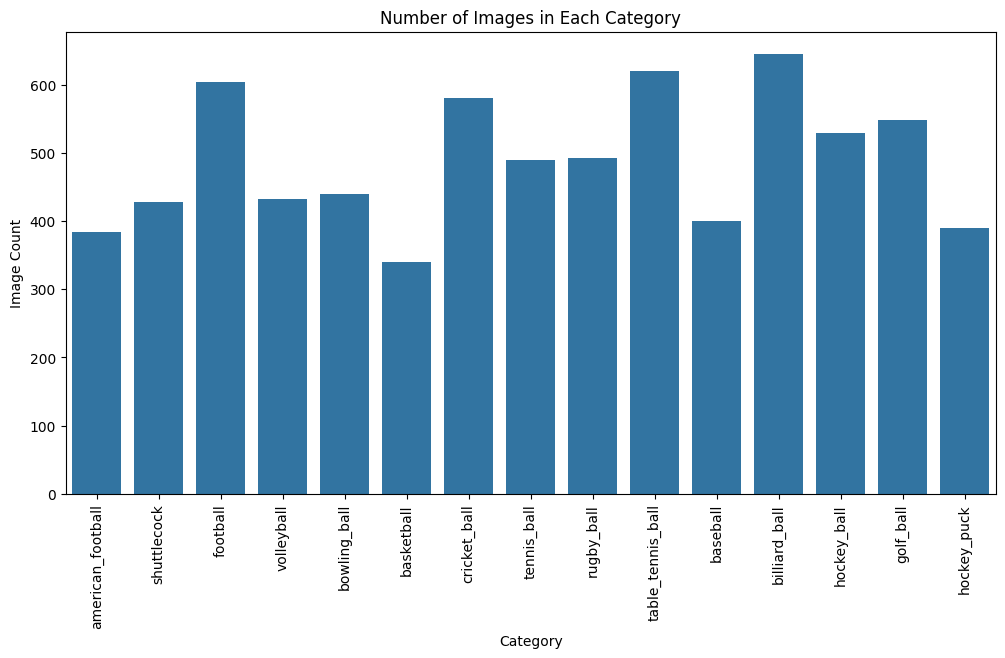

In [17]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Directory path (update with the correct path)
train_dir = "/content/train"

# Dictionary to store subdirectory names and file counts
data = {
    "Category": [],
    "Image Count": []
}

# Loop through each subdirectory in train_dir
for sub_dir in os.listdir(train_dir):
    sub_dir_path = os.path.join(train_dir, sub_dir)

    # Check if it is a directory
    if os.path.isdir(sub_dir_path):

        # Count number of image files
        num_files = len([
            f for f in os.listdir(sub_dir_path)
            if os.path.isfile(os.path.join(sub_dir_path, f))
        ])

        # Store the results
        data["Category"].append(sub_dir)
        data["Image Count"].append(num_files)

# Convert the data to a pandas DataFrame
df = pd.DataFrame(data)

# Create the bar plot using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x="Category", y="Image Count", data=df)
plt.xticks(rotation=90)
plt.title("Number of Images in Each Category")
plt.ylabel("Image Count")
plt.xlabel("Category")
plt.show()

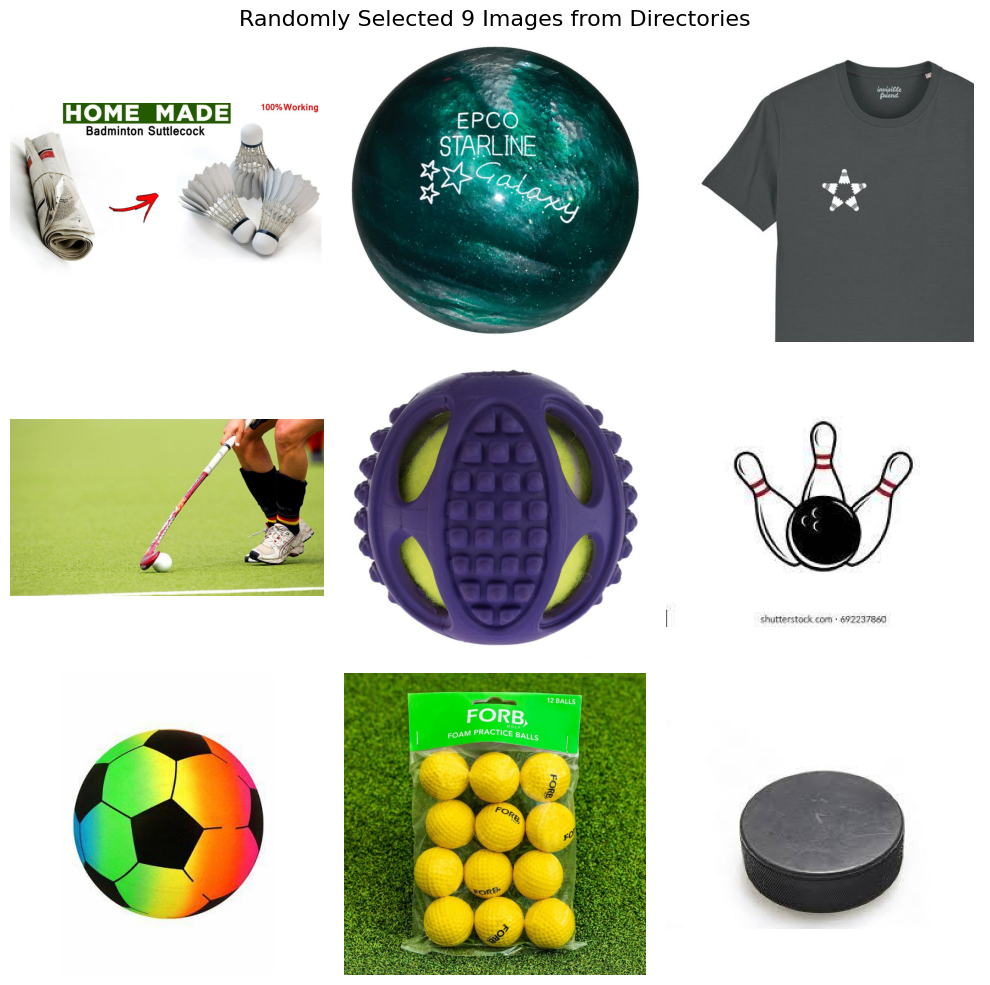

In [18]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory path (update with your correct path)
train_dir = "/content/train"

# List to store all image paths
all_images = []

# Loop through all subdirectories and collect file paths
for sub_dir in os.listdir(train_dir):
    sub_dir_path = os.path.join(train_dir, sub_dir)

    if os.path.isdir(sub_dir_path):
        all_images.extend(
            os.path.join(sub_dir_path, f)
            for f in os.listdir(sub_dir_path)
            if os.path.isfile(os.path.join(sub_dir_path, f))
        )

# Randomly select 9 images
random_images = random.sample(all_images, 9)

# Plotting the images in a 3x3 grid
plt.figure(figsize=(10, 10))
for i, image_path in enumerate(random_images):
    img = mpimg.imread(image_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")  # Turn off the axis

plt.suptitle("Randomly Selected 9 Images from Directories", fontsize=16)
plt.tight_layout()
plt.show()

### Data Preparetion


In [19]:
# Set up directory and parameters
train_dir = "/content/train"

img_size = (224, 224)   # ResNet50 standard input size
batch_size = 32         # Adjust based on GPU/CPU capacity


In [20]:
# Data Augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),     # Random horizontal flip
    layers.RandomRotation(0.1),          # Random rotation
    layers.RandomZoom(0.1),              # Random zoom
])

### FLow the directory

In [21]:
# Load training dataset (80%)
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,       # 80/20 split
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 7328 files belonging to 15 classes.
Using 5863 files for training.


In [22]:

# Load validation dataset (20%)
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

print("Classes:", train_dataset.class_names)

Found 7328 files belonging to 15 classes.
Using 1465 files for validation.
Classes: ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball', 'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock', 'table_tennis_ball', 'tennis_ball', 'volleyball']


In [23]:
# Apply data augmentation ONLY to training data
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

In [24]:
# Optional: Prefetch data for performance improvement
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

### Model Building

In [25]:
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    # 1st convolution (1×1) — reduce dimensions
    x = layers.Conv2D(filters, kernel_size=1, strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # 2nd convolution (3×3)
    x = layers.Conv2D(filters, kernel_size=kernel_size, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # 3rd convolution (1×1) — restore dimensions (filters * 4 for bottleneck)
    x = layers.Conv2D(filters * 4, kernel_size=1, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut if shape mismatch
    if stride != 1 or shortcut.shape[-1] != filters * 4:
        shortcut = layers.Conv2D(filters * 4, kernel_size=1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add shortcut connection
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x

In [26]:
# --- Build ResNet-51 style model ---
def build_resnet50(input_shape=(224, 224, 3), num_classes=15):
    inputs = tf.keras.Input(shape=input_shape)

    # Initial Conv + MaxPool (same as ResNet-50)
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    # Stage 1 (3 blocks) — Filters = 64
    x = residual_block(x, filters=64)
    x = residual_block(x, filters=64)
    x = residual_block(x, filters=64)

    # Stage 2 (4 blocks) — Filters = 128
    x = residual_block(x, filters=128, stride=2)
    x = residual_block(x, filters=128)
    x = residual_block(x, filters=128)
    x = residual_block(x, filters=128)

    # Stage 3 (6 blocks) — Filters = 256
    x = residual_block(x, filters=256, stride=2)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)

    # Stage 4 (3 blocks) — Filters = 512
    x = residual_block(x, filters=512, stride=2)
    x = residual_block(x, filters=512)
    x = residual_block(x, filters=512)

    # Global Average Pooling + Output Layer
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, x)
    return model

In [27]:
model=build_resnet50(input_shape=(224,224,3))
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     16,640 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     16,640 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ add[0][0]       

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 23,565,327 (89.89 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [28]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy']
              )

In [29]:
history=model.fit(
      train_dataset,
      epochs=5,
      validation_data=validation_dataset
  )

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 185s 688ms/step - accuracy: 0.1689 - loss: 2.8808 - val_accuracy: 0.0853 - val_loss: 6.7202
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 99s 538ms/step - accuracy: 0.2439 - loss: 2.4311 - val_accuracy: 0.2089 - val_loss: 2.4774
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 99s 537ms/step - accuracy: 0.2685 - loss: 2.3210 - val_accuracy: 0.1659 - val_loss: 2.5987
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 98s 530ms/step - accuracy: 0.3070 - loss: 2.1947 - val_accuracy: 0.3038 - val_loss: 2.3034
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 144s 541ms/step - accuracy: 0.3357 - loss: 2.1162 - val_accuracy: 0.2635 - val_loss: 2.3776


### Pretrained model and fine tuning

In [30]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models



In [31]:
# Set up directory and parameters
train_dir = "/content/train"
img_size = (224, 224)
batch_size = 32
num_classes = 15   # Update with your actual number of classes

# Load pre-trained ResNet50 WITHOUT top layers
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)



In [32]:
# Freeze the base model
base_model.trainable = False

# Input layer
inputs = tf.keras.Input(shape=(224, 224, 3))

# Normalization
x = layers.Rescaling(1./255)(inputs)

# Pass through pre-trained base model
x = base_model(x, training=False)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Fully Connected Layer
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)  # Reduce overfitting

# Final Output Layer
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Build the model
model = models.Model(inputs, outputs)



In [33]:
# Show summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,116,111 (92.00 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



In [35]:
# Load training and validation datasets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 7328 files belonging to 15 classes.
Using 5863 files for training.


In [36]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)



Found 7328 files belonging to 15 classes.
Using 1465 files for validation.


In [37]:
# Prefetch for performance
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)



In [38]:
# Train the model (base model is frozen)
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5   # Adjust as needed
)

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 45s 187ms/step - accuracy: 0.1075 - loss: 2.7008 - val_accuracy: 0.1249 - val_loss: 2.6207
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.1233 - loss: 2.6214 - val_accuracy: 0.1345 - val_loss: 2.5855
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - accuracy: 0.1298 - loss: 2.6008 - val_accuracy: 0.1686 - val_loss: 2.5652
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.1431 - loss: 2.5869 - val_accuracy: 0.1570 - val_loss: 2.5650
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.1518 - loss: 2.5623 - val_accuracy: 0.1884 - val_loss: 2.5382
